<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000

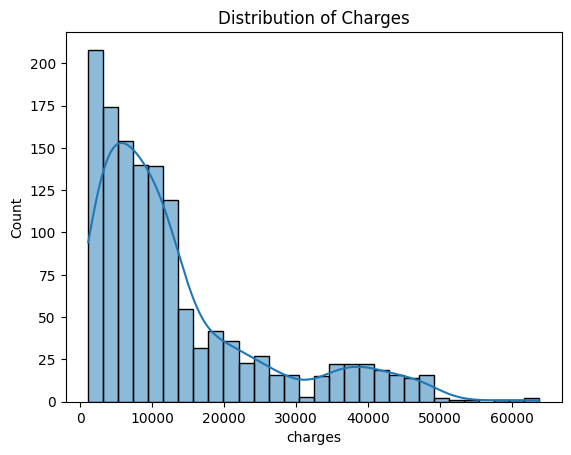

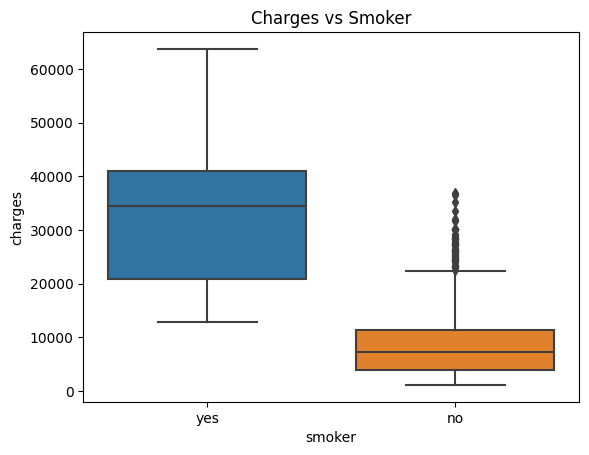

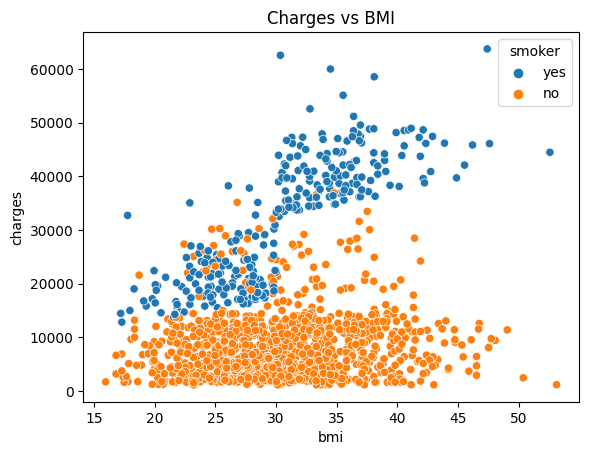

MAE: 2530.68
RMSE: 4486.12
R2 Score: 0.87


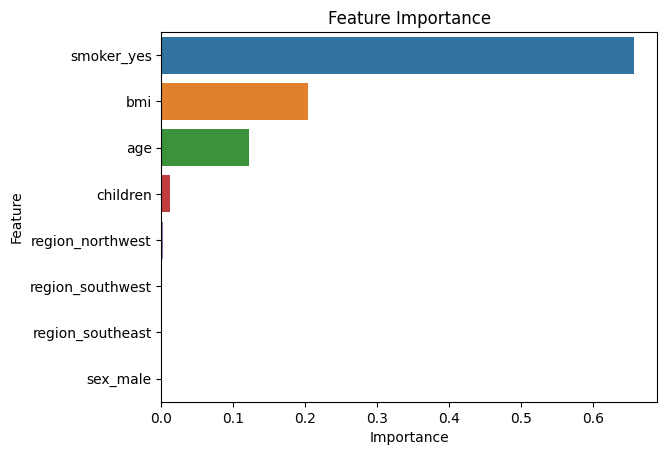

Predicted Insurance Charges: [ 2712.16351455 35872.37919085 14548.30470716]


In [1]:
# 1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# 2 Load CSV file
df = pd.read_csv("/kaggle/input/medical-insurance-data/insurance.csv")

# View first 5 rows
df.head()

# 3 Exploratory Data Analysis (EDA)
# Check dataset info
df.info()

# Check missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())

# Visualizations
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.show()

sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges vs Smoker')
plt.show()

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI')
plt.show()

# 4 Preprocessing
# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Categorical and numerical features
cat_features = ['sex', 'smoker', 'region']
num_features = ['age', 'bmi', 'children']

# Preprocessing pipelines
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6 Build Pipeline & Train Models

# Example with Gradient Boosting
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42))
])

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

# 7 Feature Importance (from Gradient Boosting)
importances = model.named_steps['regressor'].feature_importances_
features = num_features + list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out())

feat_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance')
plt.show()

# 8 Test Predictions for Sample Data
sample_data = pd.DataFrame({
    'age': [25, 40, 60],
    'sex': ['male', 'female', 'male'],
    'bmi': [22.5, 30.1, 28.7],
    'children': [0, 2, 1],
    'smoker': ['no', 'yes', 'no'],
    'region': ['southwest', 'southeast', 'northwest']
})

predictions = model.predict(sample_data)
print("Predicted Insurance Charges:", predictions)












Linear Regression MAE: 4181.19
Linear Regression RMSE: 5796.28
Linear Regression R2 Score: 0.78


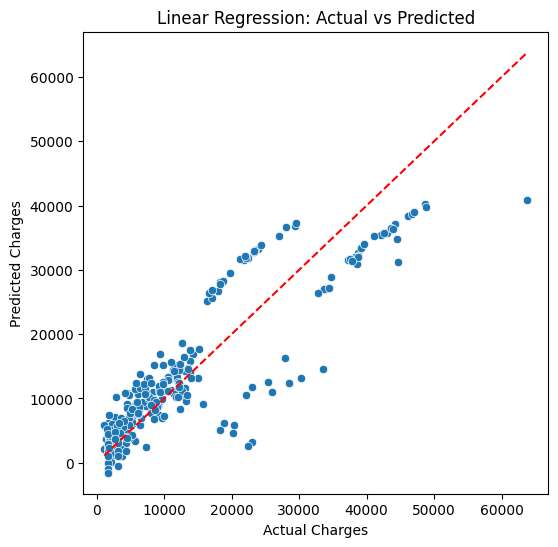

In [2]:
# 1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 2 Load CSV file
df = pd.read_csv("/kaggle/input/medical-insurance-data/insurance.csv")

# View first 5 rows
df.head()

# 3 Preprocessing
X = df.drop('charges', axis=1)
y = df['charges']

cat_features = ['sex', 'smoker', 'region']
num_features = ['age', 'bmi', 'children']

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 4 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5 Build Pipeline & Train Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)

# 6 Predict
y_pred_lr = linear_model.predict(X_test)

# 7 Evaluate Model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R2 Score: {r2_lr:.2f}")

# 8 Visualize Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


Random Forest MAE: 2521.98
Random Forest RMSE: 4548.38
Random Forest R2 Score: 0.87


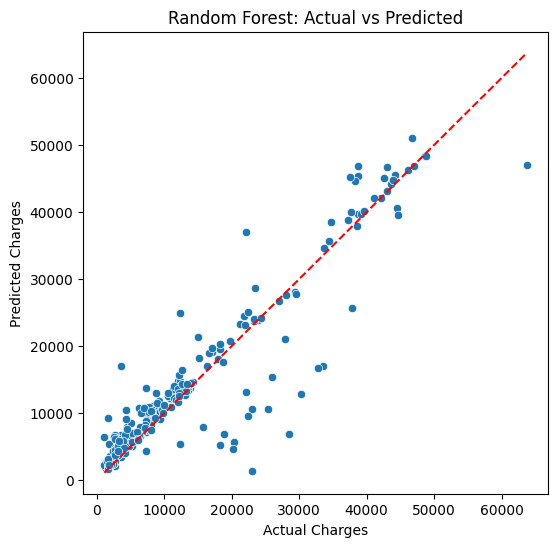

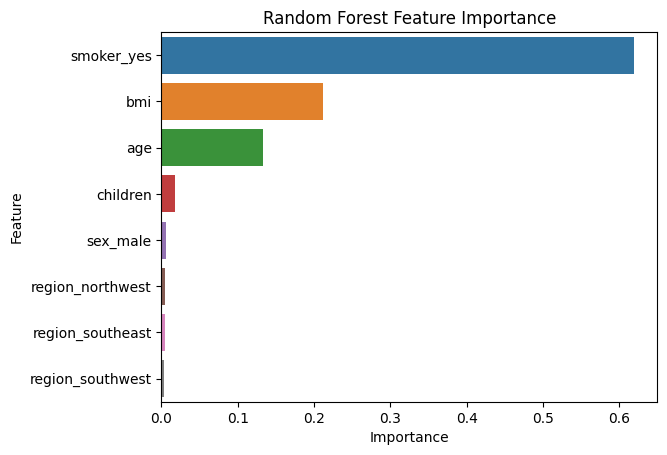

In [3]:
# 1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 2 Load CSV file
df = pd.read_csv("/kaggle/input/medical-insurance-data/insurance.csv")

# View first 5 rows
df.head()

# 3 Preprocessing
X = df.drop('charges', axis=1)
y = df['charges']

cat_features = ['sex', 'smoker', 'region']
num_features = ['age', 'bmi', 'children']

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 4 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5 Build Pipeline & Train Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

rf_model.fit(X_train, y_train)

# 6 Predict
y_pred_rf = rf_model.predict(X_test)

# 7 Evaluate Model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R2 Score: {r2_rf:.2f}")

# 8 Visualize Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 9 Feature Importance
importances = rf_model.named_steps['regressor'].feature_importances_
features = num_features + list(rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out())

feat_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Random Forest Feature Importance')
plt.show()
